# Digital High-Pass Filter

In this section, we are going to do the following activities:

- discretize a continuous-time high-pass filter by using bilinear transform (trapezoidal or Tustin) method
- implement the discretized high-pass filter into MATLAB Simulink
- compare the results from the implemented discrete high-pass filter to the shipped discrete high-pass filter in MATLAB Simulink

## Required Imports

In [45]:
from IPython.core.display import HTML
from sympy import *
from mathprint import *

In [46]:
Ts, tau = symbols('T_s tau', positive=True)
s = symbols('s', complex=True)
z = symbols('z')
omega    = symbols('omega'   , positive=True)
wc = symbols('omega_c', positive=True)

x, y = symbols('x y')
x0, x1, x2, x3 = symbols('x_k x_{k-1} x_{k-2} x_{k-3}')
y0, y1, y2, y3 = symbols('y_k y_{k-1} y_{k-2} y_{k-3}')

---


## First-Order High-Pass Filter
### The Complementary Form

Transfer function of a first-order highpass filter as a complementary to  a first-order lowpass filter(time-constant filter):

$$ H_{HP}(s) = 1 - H_{LP}$$


$$ H(s) = 1 - \frac{1}  {\tau s+1} $$

where $\tau$ is the filter time constant (in seconds).

__Discretization with Bilinear Transformation__

Next, we transform $s$ into $z$ by applying the following substitution.

$$ \frac{1}{s} \longleftarrow \frac{T_s}{2} \frac{z+1}{z-1} $$

In [47]:
H = 1 - 1 / (tau*s+1)
mprint('H=',latex(H))

H = H.subs(1/s, Ts/2 * (z+1)/(z-1))
mprint('H=',latex(H))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Let us define $x$ as the input to the filter and $y$ as the output (filtered input).

In [48]:
eq = Eq(y, H * x)
mprint(latex(eq))

eq = simplify(eq)
mprint(latex(eq))

eq = Eq(numer(eq.rhs), expand(eq.lhs * denom(eq.rhs)))
mprint(latex(eq))

eq =expand(Eq(numer(eq.rhs)/z/Ts, eq.lhs * denom(eq.rhs)/z/Ts))
mprint(latex(eq))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Apply the following substitutions:

* $y$ becomes $y_{k}$
* $y/z$ becomes $y_{k-1}$
* $x$ becomes $x_{k}$
* $x/z$ becomes $x_{k-1}$

In [49]:
eq = eq.subs(x/z**3, x3).subs(x/z**2, x2).subs(x/z, x1).subs(x, x0).subs(y/z**3, y3).subs(y/z**2, y2).subs(y/z, y1).subs(y, y0)
mprint("\\small ", latex(eq))

<IPython.core.display.Math object>

Finally, by grouping the variables, we obtain:

In [50]:
eq = Eq(collect(eq.rhs, [2,tau/Ts, x0, x1, x2, x3]), collect(eq.lhs, [y0, y1, y2, y3]) )
mprintb("\\small ", latex(eq))

<IPython.core.display.Math object>

----

## Second Order High-Pass Butterworth Filter

### The Complementary Form
Transfer function of a second order highpass filter as a complementary to a second-order lowpass filter (Butterworth):

$$ H_{HP}(s) = 1 - H_{LP}$$

$$ H(s) = 1 - \frac{\omega_{c}^{2}}{\omega_{c}^{2} + \sqrt{2} \omega_{c} s + s^{2}} $$

where $\omega_c$ is the filter cut-off frequency (in Hz).


__Discretization with Bilinear Transformation__

Similiar to the previous section, here we also transform $s$ into $z$ by applying the following substitution.

$$ \frac{1}{s} \longleftarrow \frac{T_s}{2} \frac{z+1}{z-1} $$

In [51]:
H = 1 - wc**2 / (wc**2+sqrt(2)*s*wc+s**2)
mprint('H=',latex(H))

H = simplify(1 - wc**2 / (wc**2+sqrt(2)*s*wc+s**2))
mprint('H=',latex(H))

H = simplify(H.subs(1/s, Ts/2 * (z+1)/(z-1)))
mprint('H=',latex(H))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Let us define $x$ as the input to the filter and $y$ as the output (filtered input).

In [52]:
eq = Eq(y, H * x)
mprint(latex(eq))

eq = simplify(eq)
mprint(latex(eq))

eq = Eq(numer(eq.rhs), expand(eq.lhs * denom(eq.rhs)))
mprint(latex(eq))

eq =expand(Eq(numer(eq.rhs)/z**2/Ts**2/wc**2, eq.lhs * denom(eq.rhs)/z**2/Ts**2/wc**2))
mprint(latex(eq))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Apply the following substitutions:

* $y$ becomes $y_{k}$
* $y/z$ becomes $y_{k-1}$
* $y/z^2$ becomes $y_{k-2}$
* $x$ becomes $x_{k}$
* $x/z$ becomes $x_{k-1}$
* $x/z^2$ becomes $x_{k-2}$

In [53]:
eq = eq.subs(x/z**3, x3).subs(x/z**2, x2).subs(x/z, x1).subs(x, x0).subs(y/z**3, y3).subs(y/z**2, y2).subs(y/z, y1).subs(y, y0)
mprint(latex(eq))

<IPython.core.display.Math object>

Finally, by grouping the variables, we obtain:

In [54]:
eq = Eq(collect(eq.rhs, [x0, x1, x2, x3]), collect(eq.lhs, [y0, y1, y2, y3]) )
mprintb(latex(eq))

<IPython.core.display.Math object>

__However, the complementary form does NOT have +40 dB/decade at $\omega=\omega_c$.__

In [55]:
H = simplify(1 - wc**2 / (wc**2+sqrt(2)*s*wc+s**2))
Hjw = H.subs(s, I*omega)

M = 20*log(abs(Hjw))/log(10)
mprint('M(j\\omega)=', latex(M))

dM = simplify(diff(M, omega))
mprint('\\frac{dM}{d\\omega}=', latex(dM))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

When $\omega = \omega_c$:

In [56]:
limit(dM, omega, wc).evalf()

2.89529654602168/omega_c

However, the unit here is `dB/(rad/s)`, not `dB/decade`.
To obtain `dB/decade`:

In [57]:
Sdec = simplify(omega * log(10) * dM)
Sdec

40*omega_c**2*(-omega**4 + omega**2*omega_c**2 + omega_c**4)/(omega**6 + 2*omega**4*omega_c**2 + omega**2*omega_c**4 + 2*omega_c**6)

<IPython.core.display.Math object>

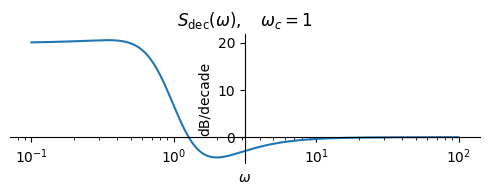

In [58]:
Sdec_wc1 = simplify(Sdec.subs(wc, 1))

mprint(
    r'S_{\mathrm{dec}}(\omega)\big|_{\omega_c=1}=',
    latex(Sdec_wc1)
)

p = plot(
    Sdec_wc1,
    (omega, 0.1, 100),
    size=(5, 2),
    show=False,
    title=r'$S_{\mathrm{dec}}(\omega),\quad \omega_c=1$',
    xlabel=r'$\omega$',
    ylabel=r'dB/decade',
    xscale='log'
)

p.show()

In [59]:
Sdec_wc = simplify(Sdec.subs(omega, wc))
Sdec_wc

20/3

Thus, it is only about 6.7 dB / decade!

In [60]:
Sdec_low = simplify(limit(Sdec, omega, 0, dir='+'))
Sdec_high = simplify(limit(Sdec, omega, oo))

mprint(
    r'\lim_{\omega\to0}S_{\mathrm{dec}}(\omega)=',
    latex(Sdec_low)
)

mprint(
    r'\lim_{\omega\to\infty}S_{\mathrm{dec}}(\omega)=',
    latex(Sdec_high)
)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

The complementary form has an asymptotic low-frequency slope of only +20 dB/decade, rather than the +40 dB/decade of a conventional second-order HPF. At the cutoff, its local slope is approximately +6.67 dB/decade.

### Standard Form

In [61]:
H = s**2 / (wc**2+sqrt(2)*s*wc+s**2)
mprint('H=',latex(H))

<IPython.core.display.Math object>

In [62]:
H = simplify(H.subs(1/s, Ts/2 * (z+1)/(z-1)))
mprint('H=',latex(H))

<IPython.core.display.Math object>

In [63]:
eq = Eq(y, H * x)
mprint(latex(eq))

eq = simplify(eq)
mprint(latex(eq))

eq = Eq(numer(eq.rhs), expand(eq.lhs * denom(eq.rhs)))
mprint(latex(eq))

eq =expand(Eq(numer(eq.rhs)/z**2/Ts**2/wc**2, eq.lhs * denom(eq.rhs)/z**2/Ts**2/wc**2))
mprint(latex(eq))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [64]:
eq = eq.subs(x/z**3, x3).subs(x/z**2, x2).subs(x/z, x1).subs(x, x0).subs(y/z**3, y3).subs(y/z**2, y2).subs(y/z, y1).subs(y, y0)
mprint(latex(eq))

<IPython.core.display.Math object>

In [65]:
eq = Eq(collect(eq.rhs, [x0, x1, x2, x3]), collect(eq.lhs, [y0, y1, y2, y3]) )
mprintb(latex(eq))

<IPython.core.display.Math object>

### Implementation in Simulink

```octave
function y = HPF(y1, y2, x0, x1, x2, wc, Ts)
% Second-order Butterworth high-pass filter
%
% y1 = y(k-1)
% y2 = y(k-2)
% x0 = x(k)
% x1 = x(k-1)
% x2 = x(k-2)
% wc = cutoff angular frequency [rad/s]
% Ts = sampling period [s]

sq22 = 2*sqrt(2);
Tswc = Ts * wc;

A = 1 + sq22/Tswc + 4/Tswc^2;
B = 2 - 8/Tswc^2;
C = 1 - sq22/Tswc + 4/Tswc^2;
D = 4/Tswc^2;

y = (D*(x0 - 2*x1 + x2) - B*y1 - C*y2) / A;
end
```

[Download Simulink file here.](./downloads/hpfbuttter2nd.slx)

![](./images/p27.png)

![](./images/p28.png)